# Initial Public Data Exploration

## Purpose

This notebook validates the format and basic usability of a small sample of publicly available NYISO load and day-ahead price data.

This is an independent educational project using only public data, personal equipment, personal accounts, and personal time. No NYISO nonpublic information, internal work product, systems, or employment-derived information is used.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

RAW_DATA_DIR, FIGURES_DIR

(WindowsPath('C:/Users/zisho/Documents/Power_Trading_Transition/02_Projects/nyiso-power-market-analytics/data/raw'),
 WindowsPath('C:/Users/zisho/Documents/Power_Trading_Transition/02_Projects/nyiso-power-market-analytics/outputs/figures'))

In [2]:
list(RAW_DATA_DIR.glob("*"))

[WindowsPath('C:/Users/zisho/Documents/Power_Trading_Transition/02_Projects/nyiso-power-market-analytics/data/raw/.ipynb_checkpoints'),
 WindowsPath('C:/Users/zisho/Documents/Power_Trading_Transition/02_Projects/nyiso-power-market-analytics/data/raw/LBMP'),
 WindowsPath('C:/Users/zisho/Documents/Power_Trading_Transition/02_Projects/nyiso-power-market-analytics/data/raw/Load')]

In [3]:
from pathlib import Path

print("Raw data directory:")
for item in RAW_DATA_DIR.iterdir():
    print(item.name)

Raw data directory:
.ipynb_checkpoints
LBMP
Load


In [19]:
LBMP_DIR = RAW_DATA_DIR / "LBMP"

lbmp_files = sorted(LBMP_DIR.glob("*.csv"))

print(f"Number of LBMP CSV files found: {len(lbmp_files)}")
print("First 10 files:")
for file in lbmp_files[:10]:
    print("-", file.name)

Number of LBMP CSV files found: 599
First 10 files:
- damlbmp_zone-20250101.csv
- damlbmp_zone-20250102.csv
- damlbmp_zone-20250103.csv
- damlbmp_zone-20250104.csv
- damlbmp_zone-20250105.csv
- damlbmp_zone-20250106.csv
- damlbmp_zone-20250107.csv
- damlbmp_zone-20250108.csv
- damlbmp_zone-20250109.csv
- damlbmp_zone-20250110.csv


In [20]:
lbmp_frames = []
failed_files = []

for file_path in lbmp_files:
    try:
        df = pd.read_csv(file_path)

        df["source_file"] = file_path.name

        lbmp_frames.append(df)

    except Exception as error:
        failed_files.append(
            {
                "file": file_path.name,
                "error": str(error),
            }
        )

lbmp_all_raw = pd.concat(lbmp_frames, ignore_index=True)

print(f"Successfully loaded files: {len(lbmp_frames)}")
print(f"Failed files: {len(failed_files)}")
print(f"Combined LBMP rows: {len(lbmp_all_raw):,}")
print(f"Combined LBMP columns: {lbmp_all_raw.columns.tolist()}")

if failed_files:
    display(pd.DataFrame(failed_files))

Successfully loaded files: 599
Failed files: 0
Combined LBMP rows: 215,625
Combined LBMP columns: ['Time Stamp', 'Name', 'PTID', 'LBMP ($/MWHr)', 'Marginal Cost Losses ($/MWHr)', 'Marginal Cost Congestion ($/MWHr)', 'source_file']


In [21]:
lbmp_all = lbmp_all_raw.copy()

lbmp_all["timestamp"] = pd.to_datetime(
    lbmp_all["Time Stamp"],
    format="%m/%d/%Y %H:%M",
    errors="coerce",
)

lbmp_all = lbmp_all.rename(
    columns={
        "Name": "zone",
        "LBMP ($/MWHr)": "lbmp_mwh",
        "Marginal Cost Losses ($/MWHr)": "losses_mwh",
        "Marginal Cost Congestion ($/MWHr)": "congestion_mwh",
    }
)

lbmp_all = lbmp_all[
    [
        "timestamp",
        "zone",
        "PTID",
        "lbmp_mwh",
        "losses_mwh",
        "congestion_mwh",
        "source_file",
    ]
].copy()

lbmp_all = lbmp_all.dropna(subset=["timestamp", "zone", "lbmp_mwh"])
lbmp_all = lbmp_all.sort_values(["timestamp", "zone"]).reset_index(drop=True)

print("Cleaned LBMP rows:", f"{len(lbmp_all):,}")
print("LBMP period:", lbmp_all["timestamp"].min(), "to", lbmp_all["timestamp"].max())
print("Duplicate timestamp-zone rows:", lbmp_all.duplicated(["timestamp", "zone"]).sum())

display(lbmp_all.head())

Cleaned LBMP rows: 215,625
LBMP period: 2025-01-01 00:00:00 to 2026-08-22 23:00:00
Duplicate timestamp-zone rows: 15


,timestamp,zone,PTID,lbmp_mwh,losses_mwh,congestion_mwh,source_file
0,2025-01-01,CAPITL,61757,33.19,1.34,0.0,damlbmp_zone-20250101.csv
1,2025-01-01,CENTRL,61754,31.06,-0.80,0.0,damlbmp_zone-20250101.csv
2,2025-01-01,DUNWOD,61760,33.19,1.34,0.0,damlbmp_zone-20250101.csv
3,2025-01-01,GENESE,61753,29.53,-2.32,0.0,damlbmp_zone-20250101.csv
4,2025-01-01,H Q,61844,32.11,0.25,0.0,damlbmp_zone-20250101.csv


In [22]:
available_dates = (
    lbmp_all.assign(date=lbmp_all["timestamp"].dt.date)
    .groupby("date")
    .agg(
        rows=("timestamp", "size"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
        locations=("zone", "nunique"),
    )
    .reset_index()
)

display(available_dates.head(20))
display(available_dates.tail(20))

print("Number of distinct LBMP dates:", len(available_dates))

,date,rows,first_timestamp,last_timestamp,locations
0,2025-01-01,360,2025-01-01,2025-01-01 23:00:00,15
1,2025-01-02,360,2025-01-02,2025-01-02 23:00:00,15
2,2025-01-03,360,2025-01-03,2025-01-03 23:00:00,15
3,2025-01-04,360,2025-01-04,2025-01-04 23:00:00,15
4,2025-01-05,360,2025-01-05,2025-01-05 23:00:00,15
5,2025-01-06,360,2025-01-06,2025-01-06 23:00:00,15
6,2025-01-07,360,2025-01-07,2025-01-07 23:00:00,15
7,2025-01-08,360,2025-01-08,2025-01-08 23:00:00,15
8,2025-01-09,360,2025-01-09,2025-01-09 23:00:00,15
9,2025-01-10,360,2025-01-10,2025-01-10 23:00:00,15


,date,rows,first_timestamp,last_timestamp,locations
579,2026-08-03,360,2026-08-03,2026-08-03 23:00:00,15
580,2026-08-04,360,2026-08-04,2026-08-04 23:00:00,15
581,2026-08-05,360,2026-08-05,2026-08-05 23:00:00,15
582,2026-08-06,360,2026-08-06,2026-08-06 23:00:00,15
583,2026-08-07,360,2026-08-07,2026-08-07 23:00:00,15
584,2026-08-08,360,2026-08-08,2026-08-08 23:00:00,15
585,2026-08-09,360,2026-08-09,2026-08-09 23:00:00,15
586,2026-08-10,360,2026-08-10,2026-08-10 23:00:00,15
587,2026-08-11,360,2026-08-11,2026-08-11 23:00:00,15
588,2026-08-12,360,2026-08-12,2026-08-12 23:00:00,15


Number of distinct LBMP dates: 599


In [24]:
LOAD_DIR = RAW_DATA_DIR / "Load"

load_files = sorted(LOAD_DIR.glob("*.csv"))

print(f"Number of load CSV files found: {len(load_files)}")
print("First 20 load files:")

for file in load_files[:20]:
    print("-", file.name)

Number of load CSV files found: 1
First 20 load files:
- nyiso_loads.csv


In [25]:
sample_load_path = load_files[0]

print("Sample load file:", sample_load_path.name)

sample_load_raw = pd.read_csv(sample_load_path)

print("Sample load shape:", sample_load_raw.shape)
print("Sample load columns:")
print(sample_load_raw.columns.tolist())

display(sample_load_raw.head())

Sample load file: nyiso_loads.csv
Sample load shape: (233, 28)
Sample load columns:
['Year', 'Month', 'Day', 'Hr1', 'Hr2', 'Hr3', 'Hr4', 'Hr5', 'Hr6', 'Hr7', 'Hr8', 'Hr9', 'Hr10', 'Hr11', 'Hr12', 'Hr13', 'Hr14', 'Hr15', 'Hr16', 'Hr17', 'Hr18', 'Hr19', 'Hr20', 'Hr21', 'Hr22', 'Hr23', 'Hr24', 'Hr25']


,Year,Month,Day,Hr1,Hr2,Hr3,Hr4,Hr5,Hr6,Hr7,...,Hr16,Hr17,Hr18,Hr19,Hr20,Hr21,Hr22,Hr23,Hr24,Hr25
0,2026,1,1,17570,17118,16746,16448,16355,16555,17069,...,19701,20832,21766,21652,21374,21003,20449,19645,18793.0,NaN
1,2026,1,2,18184,17725,17386,17244,17396,18010,19081,...,20918,21710,22414,22223,21799,21262,20575,19716,18850.0,NaN
2,2026,1,3,18213,17708,17372,17184,17233,17499,18047,...,19997,20772,21381,21243,20907,20493,19909,19195,18399.0,NaN
3,2026,1,4,17725,17198,16812,16654,16672,16908,17343,...,19731,20623,21405,21315,20983,20557,19848,18867,17998.0,NaN
4,2026,1,5,17344,16891,16666,16614,16915,17780,19324,...,21071,21605,22151,21868,21387,20700,19735,18556,17472.0,NaN


In [26]:
load_frames = []
failed_load_files = []

for file_path in load_files:
    try:
        df = pd.read_csv(file_path)

        df["source_file"] = file_path.name

        load_frames.append(df)

    except Exception as error:
        failed_load_files.append(
            {
                "file": file_path.name,
                "error": str(error),
            }
        )

load_all_raw = pd.concat(load_frames, ignore_index=True)

print(f"Successfully loaded files: {len(load_frames)}")
print(f"Failed files: {len(failed_load_files)}")
print(f"Combined load rows: {len(load_all_raw):,}")
print("Combined load columns:")
print(load_all_raw.columns.tolist())

if failed_load_files:
    display(pd.DataFrame(failed_load_files))

Successfully loaded files: 1
Failed files: 0
Combined load rows: 233
Combined load columns:
['Year', 'Month', 'Day', 'Hr1', 'Hr2', 'Hr3', 'Hr4', 'Hr5', 'Hr6', 'Hr7', 'Hr8', 'Hr9', 'Hr10', 'Hr11', 'Hr12', 'Hr13', 'Hr14', 'Hr15', 'Hr16', 'Hr17', 'Hr18', 'Hr19', 'Hr20', 'Hr21', 'Hr22', 'Hr23', 'Hr24', 'Hr25', 'source_file']


In [27]:
daily_key_columns = ["Year", "Month", "Day"]

print(
    "Duplicate daily load records:",
    load_all_raw.duplicated(daily_key_columns).sum()
)

display(
    load_all_raw[
        load_all_raw.duplicated(daily_key_columns, keep=False)
    ]
    .sort_values(daily_key_columns)
    .head(10)
)

Duplicate daily load records: 0


,Year,Month,Day,Hr1,Hr2,Hr3,Hr4,Hr5,Hr6,Hr7,...,Hr17,Hr18,Hr19,Hr20,Hr21,Hr22,Hr23,Hr24,Hr25,source_file


In [28]:
hour_columns = [f"Hr{i}" for i in range(1, 25)]

load_hourly = load_all_raw.melt(
    id_vars=["Year", "Month", "Day", "source_file"],
    value_vars=hour_columns,
    var_name="hour_label",
    value_name="load_mw",
)

load_hourly["hour"] = (
    load_hourly["hour_label"]
    .str.replace("Hr", "", regex=False)
    .astype(int)
    - 1
)

load_hourly["timestamp"] = pd.to_datetime(
    {
        "year": load_hourly["Year"],
        "month": load_hourly["Month"],
        "day": load_hourly["Day"],
        "hour": load_hourly["hour"],
    },
    errors="coerce",
)

load_hourly = load_hourly[
    [
        "timestamp",
        "load_mw",
        "source_file",
        "Year",
        "Month",
        "Day",
        "hour",
    ]
].copy()

load_hourly = (
    load_hourly
    .dropna(subset=["timestamp", "load_mw"])
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("Hourly load rows:", f"{len(load_hourly):,}")
print(
    "Load period:",
    load_hourly["timestamp"].min(),
    "to",
    load_hourly["timestamp"].max(),
)
print(
    "Duplicate hourly timestamps:",
    load_hourly.duplicated(["timestamp"]).sum(),
)
print(
    "Missing load values:",
    load_hourly["load_mw"].isna().sum(),
)

display(load_hourly.head())
display(load_hourly.tail())

Hourly load rows: 5,591
Load period: 2026-01-01 00:00:00 to 2026-08-21 23:00:00
Duplicate hourly timestamps: 0
Missing load values: 0


,timestamp,load_mw,source_file,Year,Month,Day,hour
0,2026-01-01 00:00:00,17570.0,nyiso_loads.csv,2026,1,1,0
1,2026-01-01 01:00:00,17118.0,nyiso_loads.csv,2026,1,1,1
2,2026-01-01 02:00:00,16746.0,nyiso_loads.csv,2026,1,1,2
3,2026-01-01 03:00:00,16448.0,nyiso_loads.csv,2026,1,1,3
4,2026-01-01 04:00:00,16355.0,nyiso_loads.csv,2026,1,1,4


,timestamp,load_mw,source_file,Year,Month,Day,hour
5586,2026-08-21 19:00:00,20675.0,nyiso_loads.csv,2026,8,21,19
5587,2026-08-21 20:00:00,20307.0,nyiso_loads.csv,2026,8,21,20
5588,2026-08-21 21:00:00,19448.0,nyiso_loads.csv,2026,8,21,21
5589,2026-08-21 22:00:00,18397.0,nyiso_loads.csv,2026,8,21,22
5590,2026-08-21 23:00:00,17348.0,nyiso_loads.csv,2026,8,21,23


In [29]:
load_available_dates = (
    load_hourly.assign(date=load_hourly["timestamp"].dt.date)
    .groupby("date")
    .agg(
        rows=("timestamp", "size"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
        min_load_mw=("load_mw", "min"),
        max_load_mw=("load_mw", "max"),
    )
    .reset_index()
)

display(load_available_dates.head(10))
display(load_available_dates.tail(10))

print("Number of distinct load dates:", len(load_available_dates))

,date,rows,first_timestamp,last_timestamp,min_load_mw,max_load_mw
0,2026-01-01,24,2026-01-01,2026-01-01 23:00:00,16355.0,21766.0
1,2026-01-02,24,2026-01-02,2026-01-02 23:00:00,17244.0,22414.0
2,2026-01-03,24,2026-01-03,2026-01-03 23:00:00,17184.0,21381.0
3,2026-01-04,24,2026-01-04,2026-01-04 23:00:00,16654.0,21405.0
4,2026-01-05,24,2026-01-05,2026-01-05 23:00:00,16614.0,22151.0
5,2026-01-06,24,2026-01-06,2026-01-06 23:00:00,15804.0,21127.0
6,2026-01-07,24,2026-01-07,2026-01-07 23:00:00,15279.0,20512.0
7,2026-01-08,24,2026-01-08,2026-01-08 23:00:00,14995.0,19846.0
8,2026-01-09,24,2026-01-09,2026-01-09 23:00:00,15124.0,19636.0
9,2026-01-10,24,2026-01-10,2026-01-10 23:00:00,14283.0,19158.0


,date,rows,first_timestamp,last_timestamp,min_load_mw,max_load_mw
223,2026-08-12,24,2026-08-12,2026-08-12 23:00:00,16987.0,24525.0
224,2026-08-13,24,2026-08-13,2026-08-13 23:00:00,17315.0,25050.0
225,2026-08-14,24,2026-08-14,2026-08-14 23:00:00,16699.0,23768.0
226,2026-08-15,24,2026-08-15,2026-08-15 23:00:00,15754.0,21293.0
227,2026-08-16,24,2026-08-16,2026-08-16 23:00:00,15171.0,21294.0
228,2026-08-17,24,2026-08-17,2026-08-17 23:00:00,16343.0,23417.0
229,2026-08-18,24,2026-08-18,2026-08-18 23:00:00,16610.0,23939.0
230,2026-08-19,24,2026-08-19,2026-08-19 23:00:00,16150.0,24082.0
231,2026-08-20,24,2026-08-20,2026-08-20 23:00:00,16513.0,22288.0
232,2026-08-21,24,2026-08-21,2026-08-21 23:00:00,14757.0,20675.0


Number of distinct load dates: 233


In [30]:
load_dates = set(load_hourly["timestamp"].dt.date)
lbmp_dates = set(lbmp_all["timestamp"].dt.date)

overlapping_dates = sorted(load_dates.intersection(lbmp_dates))

print(f"Number of overlapping dates: {len(overlapping_dates)}")
print("First 20 overlapping dates:")
print(overlapping_dates[:20])

print("Last 20 overlapping dates:")
print(overlapping_dates[-20:])

Number of overlapping dates: 233
First 20 overlapping dates:
[datetime.date(2026, 1, 1), datetime.date(2026, 1, 2), datetime.date(2026, 1, 3), datetime.date(2026, 1, 4), datetime.date(2026, 1, 5), datetime.date(2026, 1, 6), datetime.date(2026, 1, 7), datetime.date(2026, 1, 8), datetime.date(2026, 1, 9), datetime.date(2026, 1, 10), datetime.date(2026, 1, 11), datetime.date(2026, 1, 12), datetime.date(2026, 1, 13), datetime.date(2026, 1, 14), datetime.date(2026, 1, 15), datetime.date(2026, 1, 16), datetime.date(2026, 1, 17), datetime.date(2026, 1, 18), datetime.date(2026, 1, 19), datetime.date(2026, 1, 20)]
Last 20 overlapping dates:
[datetime.date(2026, 8, 2), datetime.date(2026, 8, 3), datetime.date(2026, 8, 4), datetime.date(2026, 8, 5), datetime.date(2026, 8, 6), datetime.date(2026, 8, 7), datetime.date(2026, 8, 8), datetime.date(2026, 8, 9), datetime.date(2026, 8, 10), datetime.date(2026, 8, 11), datetime.date(2026, 8, 12), datetime.date(2026, 8, 13), datetime.date(2026, 8, 14), dat

In [31]:
lbmp_overlap_summary = available_dates[
    available_dates["date"].isin(overlapping_dates)
].copy()

load_overlap_summary = load_available_dates[
    load_available_dates["date"].isin(overlapping_dates)
].copy()

display(lbmp_overlap_summary.head())
display(load_overlap_summary.head())

,date,rows,first_timestamp,last_timestamp,locations
365,2026-01-01,360,2026-01-01,2026-01-01 23:00:00,15
366,2026-01-02,360,2026-01-02,2026-01-02 23:00:00,15
367,2026-01-03,360,2026-01-03,2026-01-03 23:00:00,15
368,2026-01-04,360,2026-01-04,2026-01-04 23:00:00,15
369,2026-01-05,360,2026-01-05,2026-01-05 23:00:00,15


,date,rows,first_timestamp,last_timestamp,min_load_mw,max_load_mw
0,2026-01-01,24,2026-01-01,2026-01-01 23:00:00,16355.0,21766.0
1,2026-01-02,24,2026-01-02,2026-01-02 23:00:00,17244.0,22414.0
2,2026-01-03,24,2026-01-03,2026-01-03 23:00:00,17184.0,21381.0
3,2026-01-04,24,2026-01-04,2026-01-04 23:00:00,16654.0,21405.0
4,2026-01-05,24,2026-01-05,2026-01-05 23:00:00,16614.0,22151.0


In [32]:
print("LBMP period:", lbmp_all["timestamp"].min(), "to", lbmp_all["timestamp"].max())
print("Load period:", load_hourly["timestamp"].min(), "to", load_hourly["timestamp"].max())
print("Number of overlapping dates:", len(overlapping_dates))
print(overlapping_dates[:10])
print(sorted(lbmp_all["zone"].dropna().unique()))

LBMP period: 2025-01-01 00:00:00 to 2026-08-22 23:00:00
Load period: 2026-01-01 00:00:00 to 2026-08-21 23:00:00
Number of overlapping dates: 233
[datetime.date(2026, 1, 1), datetime.date(2026, 1, 2), datetime.date(2026, 1, 3), datetime.date(2026, 1, 4), datetime.date(2026, 1, 5), datetime.date(2026, 1, 6), datetime.date(2026, 1, 7), datetime.date(2026, 1, 8), datetime.date(2026, 1, 9), datetime.date(2026, 1, 10)]
['CAPITL', 'CENTRL', 'DUNWOD', 'GENESE', 'H Q', 'HUD VL', 'LONGIL', 'MHK VL', 'MILLWD', 'N.Y.C.', 'NORTH', 'NPX', 'O H', 'PJM', 'WEST']


In [34]:
ZONE_J_LABEL = "N.Y.C."

zone_j_price = (
    lbmp_all.loc[lbmp_all["zone"] == ZONE_J_LABEL]
    .copy()
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("Zone J price rows:", f"{len(zone_j_price):,}")
print(
    "Zone J price period:",
    zone_j_price["timestamp"].min(),
    "to",
    zone_j_price["timestamp"].max(),
)
print(
    "Duplicate Zone J timestamps:",
    zone_j_price.duplicated(["timestamp"]).sum(),
)

display(zone_j_price.head())

Zone J price rows: 14,375
Zone J price period: 2025-01-01 00:00:00 to 2026-08-22 23:00:00
Duplicate Zone J timestamps: 1


,timestamp,zone,PTID,lbmp_mwh,losses_mwh,congestion_mwh,source_file
0,2025-01-01 00:00:00,N.Y.C.,61761,37.11,1.43,-3.82,damlbmp_zone-20250101.csv
1,2025-01-01 01:00:00,N.Y.C.,61761,36.22,1.45,-3.96,damlbmp_zone-20250101.csv
2,2025-01-01 02:00:00,N.Y.C.,61761,34.40,1.39,-4.15,damlbmp_zone-20250101.csv
3,2025-01-01 03:00:00,N.Y.C.,61761,28.42,1.15,-0.01,damlbmp_zone-20250101.csv
4,2025-01-01 04:00:00,N.Y.C.,61761,28.31,1.11,-0.01,damlbmp_zone-20250101.csv


In [35]:
analysis_start = max(
    load_hourly["timestamp"].min(),
    zone_j_price["timestamp"].min(),
)

analysis_end = min(
    load_hourly["timestamp"].max(),
    zone_j_price["timestamp"].max(),
)

load_analysis = load_hourly.loc[
    load_hourly["timestamp"].between(analysis_start, analysis_end)
].copy()

price_analysis = zone_j_price.loc[
    zone_j_price["timestamp"].between(analysis_start, analysis_end)
].copy()

print("Analysis window:", analysis_start, "to", analysis_end)
print("Load rows in window:", f"{len(load_analysis):,}")
print("Zone J price rows in window:", f"{len(price_analysis):,}")

Analysis window: 2026-01-01 00:00:00 to 2026-08-21 23:00:00
Load rows in window: 5,591
Zone J price rows in window: 5,591


In [36]:
print(
    "Load duplicate timestamps:",
    load_analysis.duplicated(["timestamp"]).sum(),
)

print(
    "Price duplicate timestamps:",
    price_analysis.duplicated(["timestamp"]).sum(),
)

print(
    "Load missing hourly timestamps:",
    len(
        pd.date_range(
            load_analysis["timestamp"].min(),
            load_analysis["timestamp"].max(),
            freq="h",
        )
    )
    - load_analysis["timestamp"].nunique(),
)

print(
    "Price missing hourly timestamps:",
    len(
        pd.date_range(
            price_analysis["timestamp"].min(),
            price_analysis["timestamp"].max(),
            freq="h",
        )
    )
    - price_analysis["timestamp"].nunique(),
)

Load duplicate timestamps: 0
Price duplicate timestamps: 0
Load missing hourly timestamps: 1
Price missing hourly timestamps: 1


In [39]:
analysis_df = (
    price_analysis[
        [
            "timestamp",
            "zone",
            "PTID",
            "lbmp_mwh",
            "losses_mwh",
            "congestion_mwh",
        ]
    ]
    .merge(
        load_analysis[["timestamp", "load_mw"]],
        on="timestamp",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print("Merged rows:", f"{len(analysis_df):,}")
print(
    "Merged period:",
    analysis_df["timestamp"].min(),
    "to",
    analysis_df["timestamp"].max(),
)
print("Missing values:")
display(analysis_df.isna().sum())

display(analysis_df.head())

analysis_df["hour"] = analysis_df["timestamp"].dt.hour
analysis_df["day_of_week"] = analysis_df["timestamp"].dt.dayofweek
analysis_df["is_weekend"] = analysis_df["day_of_week"].isin([5, 6]).astype(int)
analysis_df["month"] = analysis_df["timestamp"].dt.month
analysis_df["date"] = analysis_df["timestamp"].dt.date

analysis_df["day_name"] = analysis_df["timestamp"].dt.day_name()

display(
    analysis_df[
        [
            "timestamp",
            "zone",
            "lbmp_mwh",
            "load_mw",
            "hour",
            "day_name",
            "month",
        ]
    ].head()
)

Merged rows: 5,590
Merged period: 2026-01-01 00:00:00 to 2026-08-21 23:00:00
Missing values:


timestamp         0
zone              0
PTID              0
lbmp_mwh          0
losses_mwh        0
congestion_mwh    0
load_mw           0
dtype: int64

,timestamp,zone,PTID,lbmp_mwh,losses_mwh,congestion_mwh,load_mw
0,2026-01-01 00:00:00,N.Y.C.,61761,106.19,5.15,0.0,17570.0
1,2026-01-01 01:00:00,N.Y.C.,61761,96.92,4.70,0.0,17118.0
2,2026-01-01 02:00:00,N.Y.C.,61761,79.26,3.77,0.0,16746.0
3,2026-01-01 03:00:00,N.Y.C.,61761,73.08,3.48,0.0,16448.0
4,2026-01-01 04:00:00,N.Y.C.,61761,73.24,3.42,0.0,16355.0


,timestamp,zone,lbmp_mwh,load_mw,hour,day_name,month
0,2026-01-01 00:00:00,N.Y.C.,106.19,17570.0,0,Thursday,1
1,2026-01-01 01:00:00,N.Y.C.,96.92,17118.0,1,Thursday,1
2,2026-01-01 02:00:00,N.Y.C.,79.26,16746.0,2,Thursday,1
3,2026-01-01 03:00:00,N.Y.C.,73.08,16448.0,3,Thursday,1
4,2026-01-01 04:00:00,N.Y.C.,73.24,16355.0,4,Thursday,1


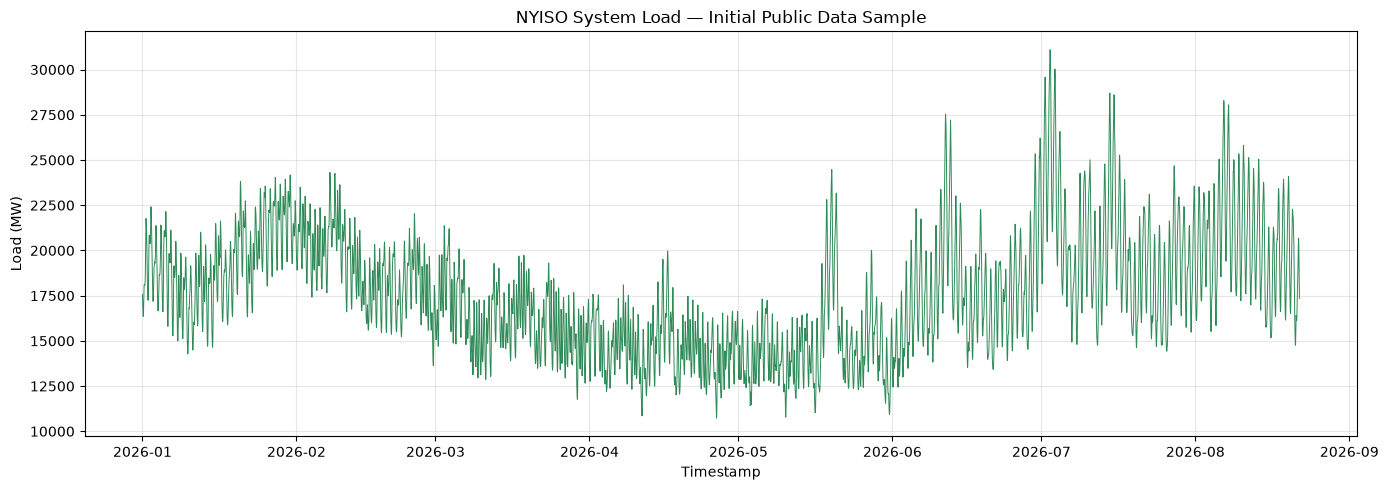

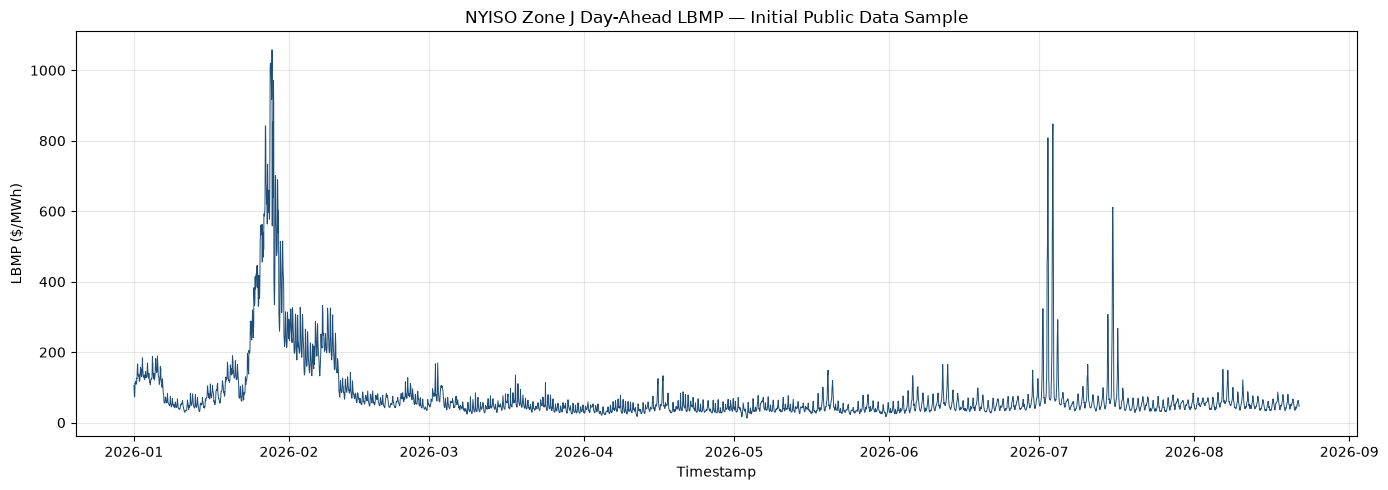

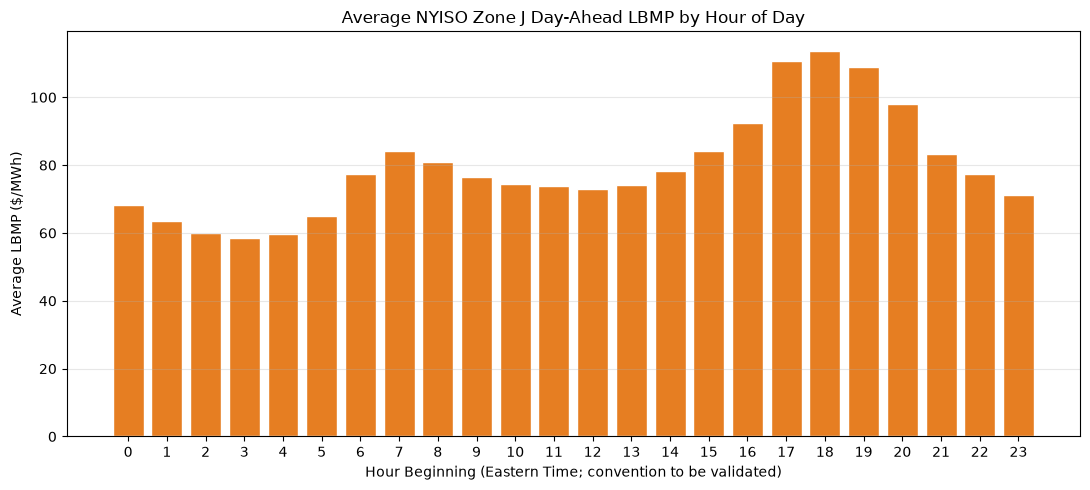

In [42]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14, 5))

plt.plot(
    analysis_df["timestamp"],
    analysis_df["load_mw"],
    color="#2E8B57",
    linewidth=0.7,
)

plt.title("NYISO System Load — Initial Public Data Sample")
plt.xlabel("Timestamp")
plt.ylabel("Load (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "nyiso_system_load_time_series.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

plt.figure(figsize=(14, 5))

plt.plot(
    analysis_df["timestamp"],
    analysis_df["lbmp_mwh"],
    color="#1F4E79",
    linewidth=0.7,
)

plt.title("NYISO Zone J Day-Ahead LBMP — Initial Public Data Sample")
plt.xlabel("Timestamp")
plt.ylabel("LBMP ($/MWh)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "zone_j_day_ahead_lbmp_time_series.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

hourly_price = (
    analysis_df.groupby("hour", as_index=False)["lbmp_mwh"]
    .mean()
)

plt.figure(figsize=(11, 5))

plt.bar(
    hourly_price["hour"],
    hourly_price["lbmp_mwh"],
    color="#E67E22",
    edgecolor="white",
)

plt.title("Average NYISO Zone J Day-Ahead LBMP by Hour of Day")
plt.xlabel("Hour Beginning (Eastern Time; convention to be validated)")
plt.ylabel("Average LBMP ($/MWh)")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "zone_j_average_lbmp_by_hour.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## Initial Findings and Validation Notes

- The analysis uses 233 overlapping dates from January 1, 2026 through August 21, 2026.
- Public NYISO system load data was reshaped from daily wide format into hourly observations.
- Public day-ahead LBMP data was filtered to the `N.Y.C.` location, representing NYISO Zone J.
- The initial merged dataset aligns Zone J day-ahead LBMP with NYISO system load by timestamp.
- The analysis uses only publicly available data downloaded to a personal device.
- Before any forecasting analysis, the project will further validate timestamp conventions, daylight-saving-time treatment, missing observations, and the timing of each publicly available feature.
- The charts are descriptive only and do not demonstrate a trading strategy, causality, or profitability.

## Next Steps

1. Validate hourly timestamp conventions for both load and day-ahead price datasets.
2. Review duplicate timestamps and missing hourly intervals.
3. Add calendar features: hour of day, day of week, weekend indicator, month, and season.
4. Create a simple historical-average benchmark by hour, weekday/weekend, and month.
5. Evaluate whether public load and historical price features improve the benchmark forecast.
6. Add Zone G after confirming a clear analytical purpose and consistent data coverage.

In [44]:
print("Saved figures:")

for file in sorted(FIGURES_DIR.glob("*.png")):
    print("-", file.name)

Saved figures:
- nyiso_system_load_time_series.png
- zone_j_average_lbmp_by_hour.png
- zone_j_day_ahead_lbmp_time_series.png
